## EDA

In [322]:
import pandas as pd
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import style
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
import numpy as np
from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option('display.max_columns', 44)

Cargo los valores del data set que se nos ha dado


In [323]:
data = pd.read_csv('attrition_availabledata_23.csv.gz', compression="gzip")

num_instancias, num_variables = data.shape



# Variables e instancias de la base de datos

Imprimo las instancais, las variables y los datos. ESto lo hago para poder ver qué variables son ordinales y luego clasificar las variables numéricas y categóricas.

In [324]:
print(f'Número de instancias: {num_instancias}')
print(f'Número de variables: {num_variables}')
print(data)

Número de instancias: 2940
Número de variables: 31
            hrs  absences  JobInvolvement  PerformanceRating  \
0      6.420398        19               4                  3   
1      7.615521         7               4                  3   
2      6.093781        18               3                  3   
3      6.460209         5               4                  3   
4     10.384712         2               2                  3   
...         ...       ...             ...                ...   
2935   9.259909        18               4                  3   
2936   6.774531        21               2                  3   
2937   5.673619        21               3                  3   
2938  10.535324         1               3                  3   
2939   6.140572        16               3                  3   

      EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance  Age  \
0                         2.0              2.0              3.0   28   
1                         4.0       

# Clasificacion de variables

Para ordenar las variables decido cuales son ordinales y luego clasifico las variables numericas y categóricas. He comentado las ordinales y ahora mismo solo trabajo con numericas y categoricas.

In [325]:
#ordinales = ['PerformanceRating', 'EnvirnonmentSatisfaction','JobSatisfaction', 'WorkLifeBAlance']
ordinales = []
categoricas = data.select_dtypes(include=['object']).columns.tolist()
numericas = data.select_dtypes(include=['number']).columns.tolist()



categoricas = [col for col in categoricas if col not in ordinales]
numericas = [col for col in numericas if col not in ordinales]



print(f'Variables ordinales: {ordinales}')
print(f'Variables categóricas: {categoricas}')
print(f'Variables numéricas: {numericas}')

Variables ordinales: []
Variables categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'Attrition']
Variables numéricas: ['hrs', 'absences', 'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# Columnas constantes 

Indentifico las columnas que tengan valores que siempre son los mismos (constantes). Lo hago con el numero de valores unicos que hay en una columna. Por ejemplo, si una columna tiene los valores [1,2,2,3,3,2] los valores unicos que tiene serian [1,2,3]. Las que tengan tantas instancias como valores unicos seran ids y para las que solo tengan un valor unico seran constantes. Las columnas que son constantes y el id del trabjador las quito porque no resultan relevantes para el entrenamiento

In [326]:
columnas_id = [colum for colum in data.columns if data[colum].nunique() == num_instancias]
columnas_constantes = [colum for colum in data.columns if data[colum].nunique() == 1]

print(f'Columnas constantes: {columnas_constantes}')
print(f'Columnas de ID: {columnas_id}')

columnas_a_eliminar = columnas_constantes + columnas_id
data = data.drop(columns=columnas_a_eliminar)

print(data)


Columnas constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Columnas de ID: ['EmployeeID']
            hrs  absences  JobInvolvement  PerformanceRating  \
0      6.420398        19               4                  3   
1      7.615521         7               4                  3   
2      6.093781        18               3                  3   
3      6.460209         5               4                  3   
4     10.384712         2               2                  3   
...         ...       ...             ...                ...   
2935   9.259909        18               4                  3   
2936   6.774531        21               2                  3   
2937   5.673619        21               3                  3   
2938  10.535324         1               3                  3   
2939   6.140572        16               3                  3   

      EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance  Age  \
0                         2.0              2.0              3.

# Columnas con valores faltantes

Después de ver que se han eliminado las columnas que eran innecesarias (data pasa de tener 31 columnas a 27) busco las variables que tienen valores faltantes. Primero, veo los valores faltantes de forma visual

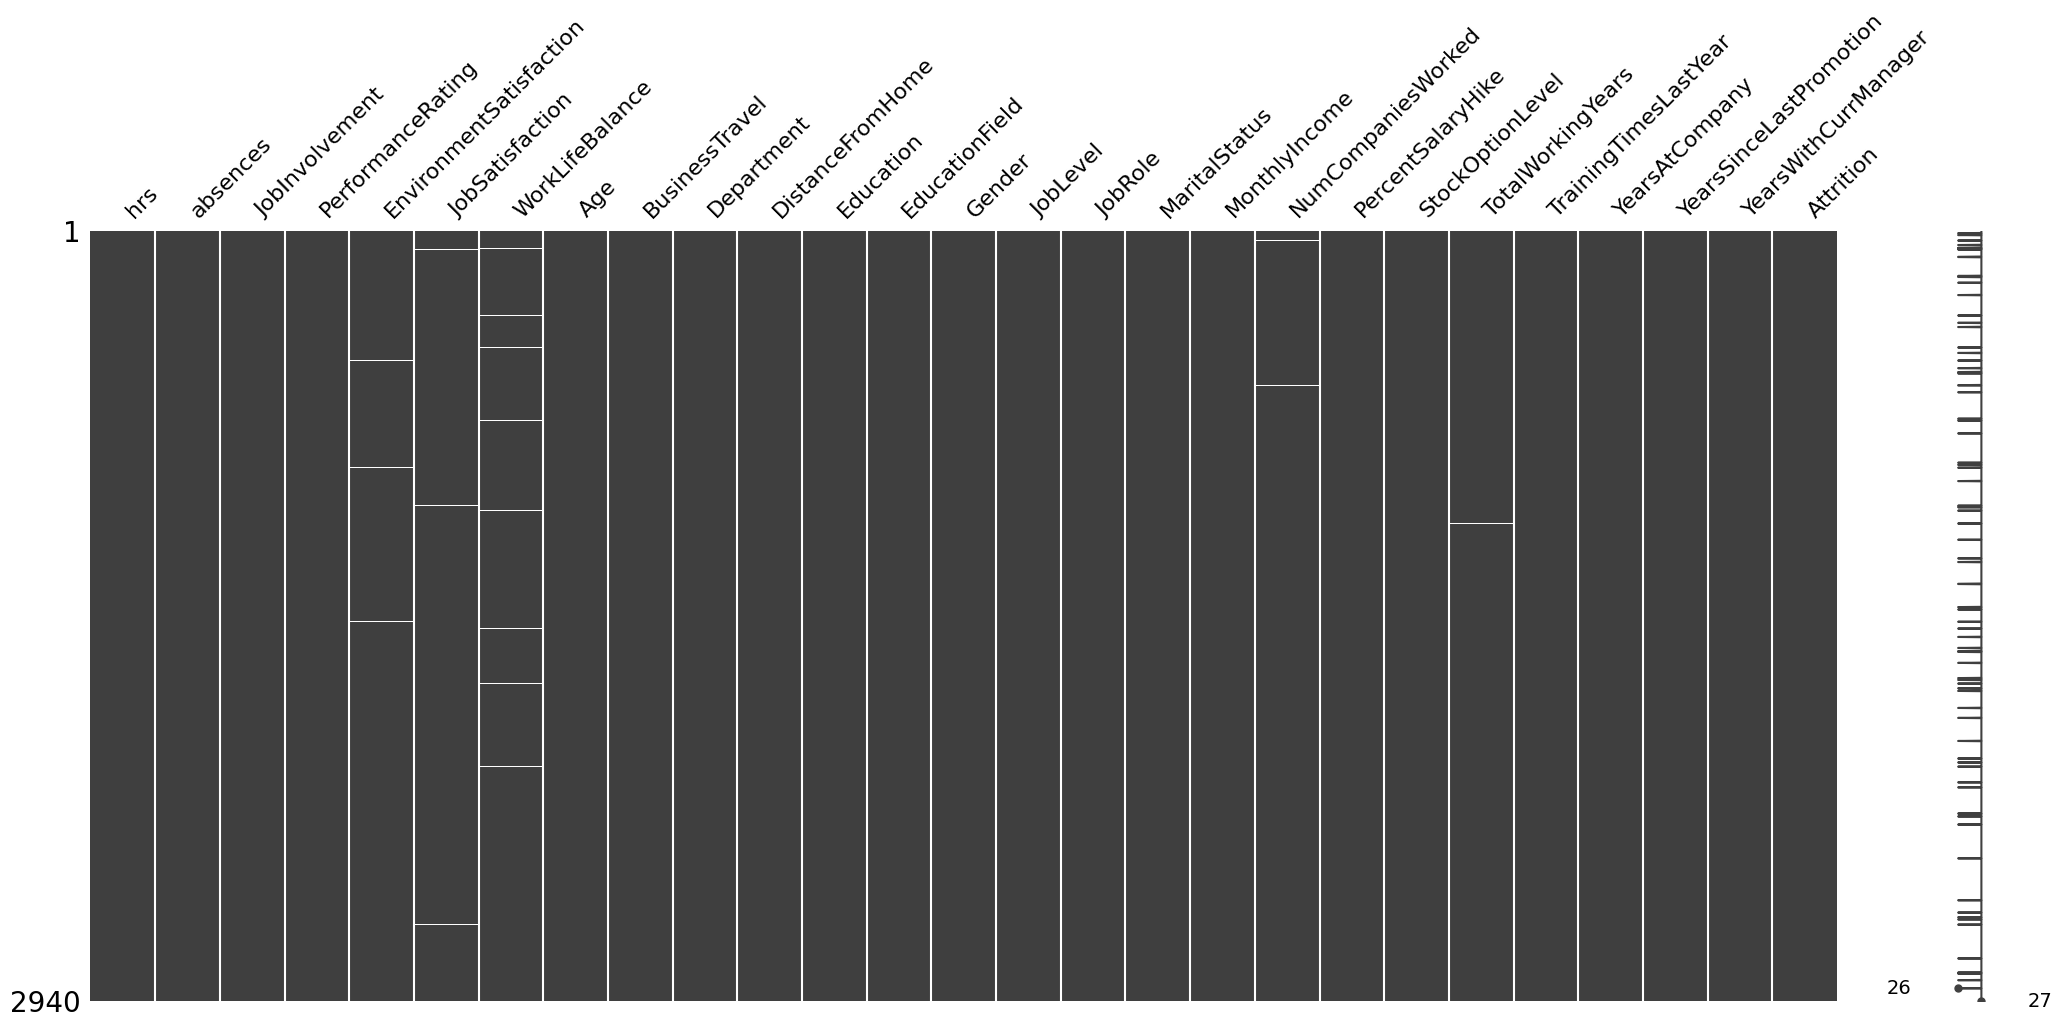

In [327]:

%matplotlib inline
%config InlineBackend.figure_format = 'png'

msno.matrix(data)
plt.show()


In [328]:
import pandas as pd
from scipy import stats

valores_faltantes = data.isnull().sum()
variables_con_faltantes = valores_faltantes[valores_faltantes > 0]

print('Variables con valores faltantes y cuántos valores faltantes tienen:')
print(variables_con_faltantes)
print('---')
columnas_con_faltantes = data.columns[data.isnull().any()]

for columna in columnas_con_faltantes:
    mediana = data[columna].median()
    moda = data[columna].mode()[0]  
    print(f'Columna: {columna}')
    print(f'Mediana: {mediana}')
    print(f'Moda: {moda}')
    print('---')



Variables con valores faltantes y cuántos valores faltantes tienen:
EnvironmentSatisfaction    18
JobSatisfaction            17
WorkLifeBalance            25
NumCompaniesWorked         11
TotalWorkingYears           6
dtype: int64
---
Columna: EnvironmentSatisfaction
Mediana: 3.0
Moda: 4.0
---
Columna: JobSatisfaction
Mediana: 3.0
Moda: 4.0
---
Columna: WorkLifeBalance
Mediana: 3.0
Moda: 3.0
---
Columna: NumCompaniesWorked
Mediana: 2.0
Moda: 1.0
---
Columna: TotalWorkingYears
Mediana: 10.0
Moda: 10.0
---


In [329]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Identificar columnas categóricas y numéricas
categorical_columns = X_train.select_dtypes(include=['object']).columns
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Lista de imputadores a probar
imputadores = {
    'SimpleImputer (mean)': SimpleImputer(strategy='mean'),
    'SimpleImputer (median)': SimpleImputer(strategy='median'),
    'SimpleImputer (most_frequent)': SimpleImputer(strategy='most_frequent'),
    'KNNImputer': KNNImputer(n_neighbors=5)
}

# Resultados de validación cruzada
resultados_imputadores = {}

# Probar cada imputador con KNN
for nombre, imputador in imputadores.items():
    # Crear un preprocesador que aplique el imputador solo a las columnas numéricas
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', imputador),  # Imputador para columnas numéricas
                ('scaler', RobustScaler ())  # Escalador para columnas numéricas
            ]), numerical_columns),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputador para columnas categóricas
                ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codificador one-hot
            ]), categorical_columns)
        ]
    )
    
    # Crear el pipeline con el preprocesador y KNN
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Preprocesador
        ('knn', KNeighborsClassifier(n_neighbors=5))  # Modelo KNN
    ])
    
    # Validación cruzada
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
    resultados_imputadores[nombre] = np.mean(scores)
    print(f"{nombre}: Balanced Accuracy promedio = {np.mean(scores):.4f}")

# Mostrar el mejor imputador
mejor_imputador = max(resultados_imputadores, key=resultados_imputadores.get)
print(f"\nEl mejor imputador es: {mejor_imputador} con un Balanced Accuracy promedio de {resultados_imputadores[mejor_imputador]:.4f}")

SimpleImputer (mean): Balanced Accuracy promedio = 0.6242
SimpleImputer (median): Balanced Accuracy promedio = 0.6242
SimpleImputer (most_frequent): Balanced Accuracy promedio = 0.6242
KNNImputer: Balanced Accuracy promedio = 0.6242

El mejor imputador es: SimpleImputer (mean) con un Balanced Accuracy promedio de 0.6242


Completo sus datos con la moda, si se trata de una variable categórica , y con la mediana, en caso de que sea numérica, ay que tienen los mismos valores en mi estudio KNN

In [330]:
columnas_con_faltantes = data.columns[data.isnull().any()]

for columna in columnas_con_faltantes:
    if data[columna].dtype in ['float64', 'int64']:  # Numérica
        mediana = data[columna].median()
        data[columna] = data[columna].fillna(mediana)  # Asignar directamente
    else:  # Categórica
        moda = data[columna].mode()[0]
        data[columna] = data[columna].fillna(moda)  # Asignar directamente

# Verificar si quedan valores faltantes
valores_faltantes = data.isnull().sum()
variables_con_faltantes = valores_faltantes[valores_faltantes > 0]

print('Variables con valores faltantes y cuántos valores faltantes tienen (después de rellenar):')
print(variables_con_faltantes)



Variables con valores faltantes y cuántos valores faltantes tienen (después de rellenar):
Series([], dtype: int64)


De nuevo, de forma visual, veo cuales variables tienen valores faltantes para ver si mi codigo funciona

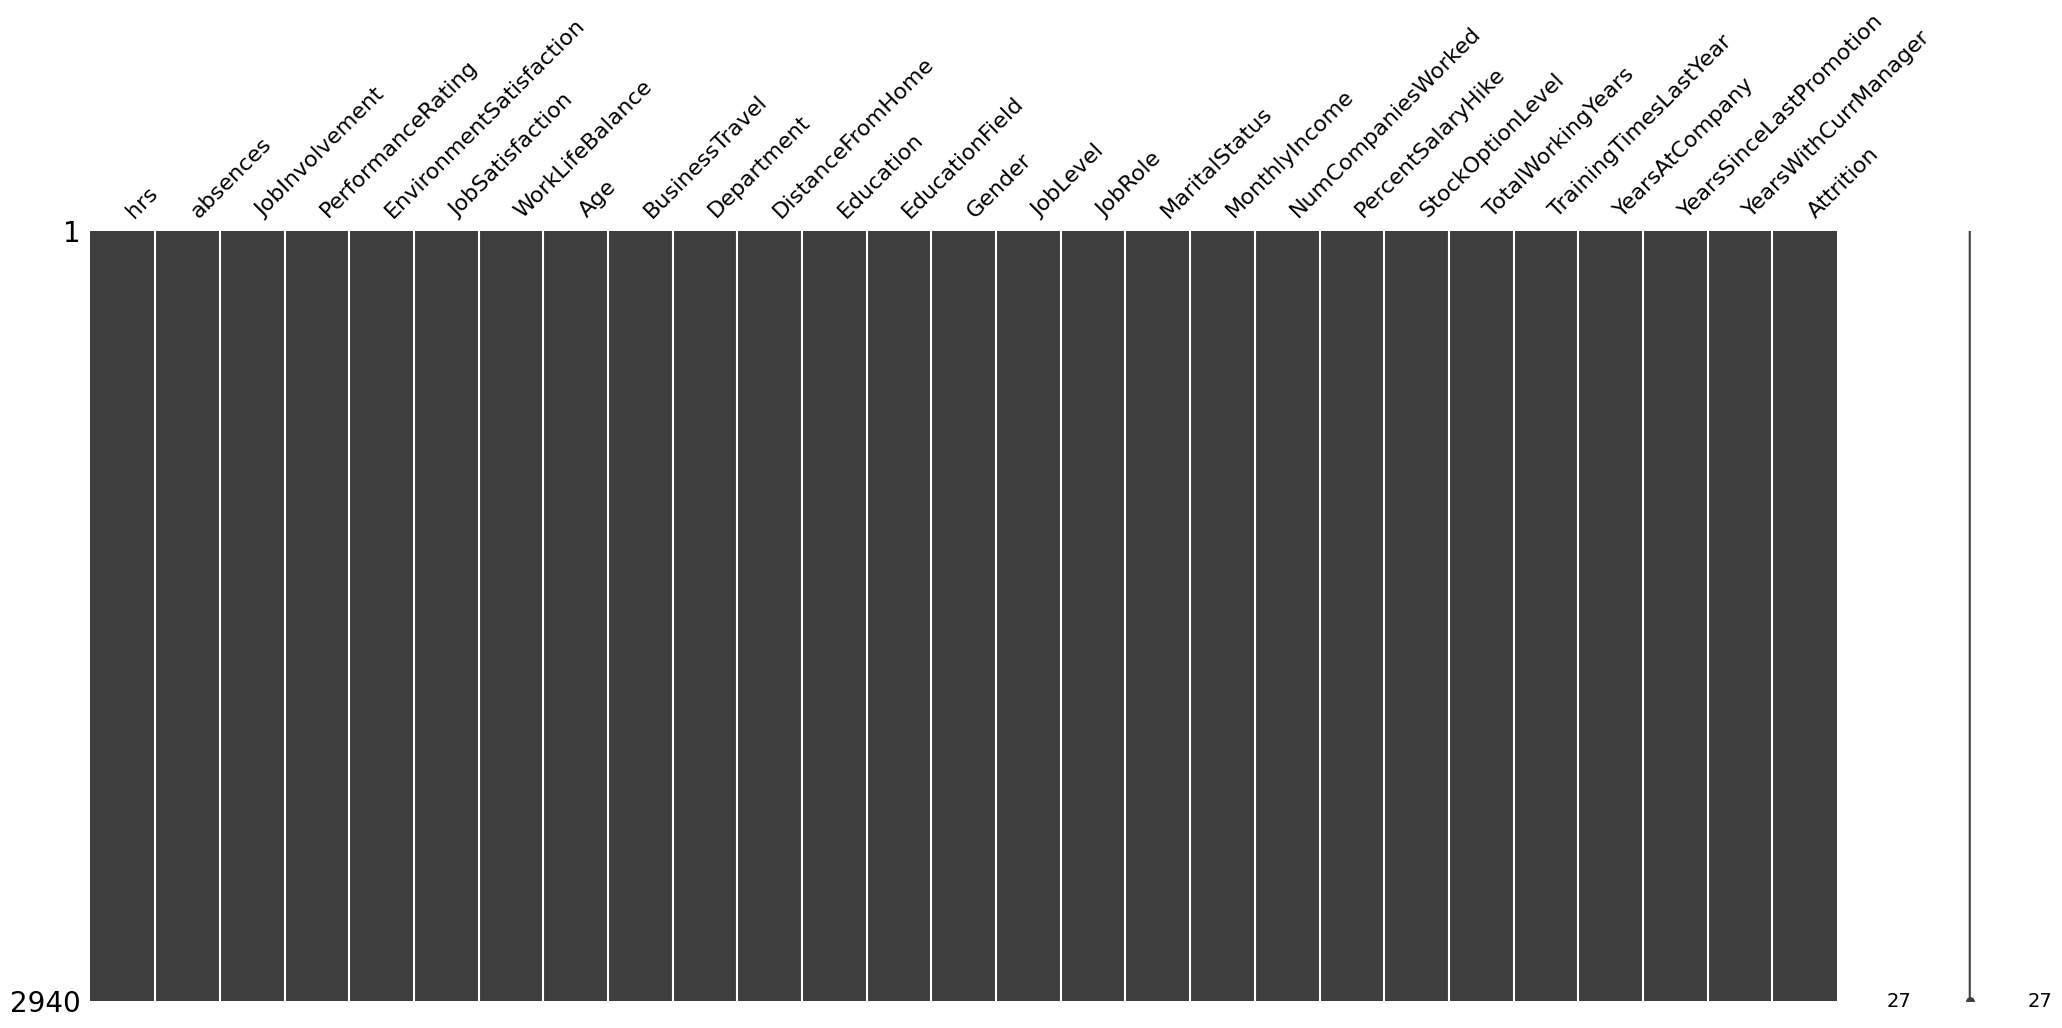

In [331]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(data)
plt.show()

## CORRELACIÓN

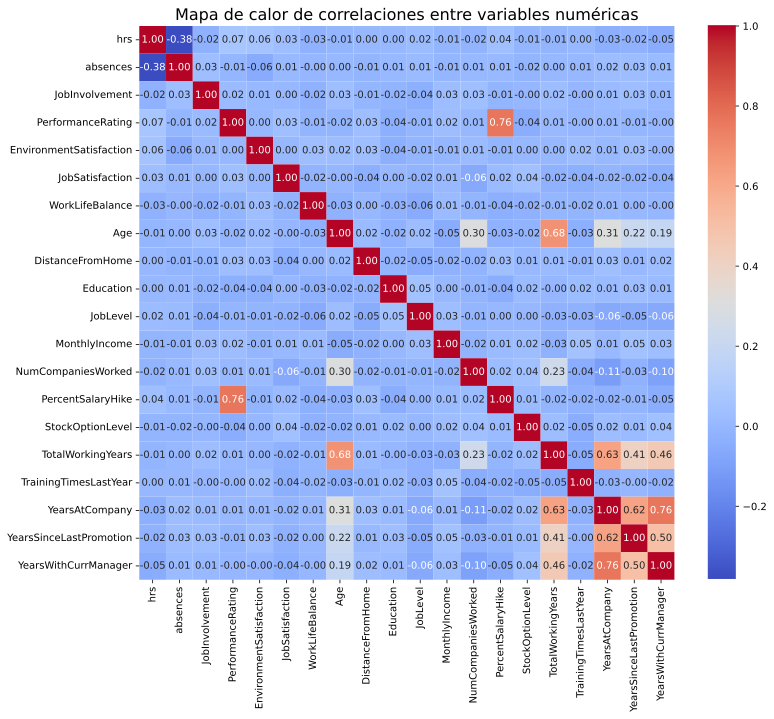

In [332]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

numericas = [col for col in numericas if col in data.columns]


# Generar el mapa de calor de correlaciones entre las variables numéricas
plt.figure(figsize=(12, 10))
g = sns.heatmap(data[numericas].corr(),
                annot=True,
                cmap="coolwarm",
                fmt=".2f")
plt.title("Mapa de calor de correlaciones entre variables numéricas", size=16)
plt.show()

He calculado la correlacion para ver si hay multicolinealidad entre alguans variables, por lo que tendria que quitar, pero como ningun valor es mayor de 0,8 considero que no hay relaciones fuertes entre dos variables de mi base de datos

# Cardinalidad de las variables categóricas

A continuación, imprimo la cardinalidad de cada variable categórica y elijo un umbral para clasificarlas como "variables de alta cardinalidad". El umbral lo he elegido tras ver los valores de mis datos considerando 6 y 9  como alta cardinalidad. Calculo la cardinalidad ahora, puesto que antes tenía una varible más que he quitado al ser irrelevante (Over18)

In [333]:
categoricas = data.select_dtypes(include=['object']).columns

print('Cardinalidad de cada variable categórica:')
for col in categoricas:
    print(f'{col}: {data[col].nunique()}')

# Establecer el umbral en 5 tras ver los valores de mis variables categóricas
umbral_cardinalidad = 5
categoricas_alta_cardinalidad = [col for col in categoricas if data[col].nunique() > umbral_cardinalidad]

print(f'Variables categóricas con alta cardinalidad (más de {umbral_cardinalidad} categorías): {categoricas_alta_cardinalidad}')

Cardinalidad de cada variable categórica:
BusinessTravel: 3
Department: 3
EducationField: 6
Gender: 2
JobRole: 9
MaritalStatus: 3
Attrition: 2
Variables categóricas con alta cardinalidad (más de 5 categorías): ['EducationField', 'JobRole']


# ¿Problema de clasficación o de regresión?

Estudio si es un problema de clasificación o regresión. 

In [334]:
objetivo = data.columns[-1]  
if data[objetivo].dtype == 'object' or len(data[objetivo].unique()) <= 20:
    problema = 'clasificación'
else:
    problema = 'regresión'

print(f'El problema es de {problema}.')

El problema es de clasificación.


Ahora que sé qué tipo de problema es, creo una variable para comprobar si el problema esta balanceado ( si hay un equilibrio entre los datos recogidos). Esto depende de la variable objetivo.

In [335]:
if problema == 'clasificación':
    clase_mayoritaria = data[objetivo].value_counts().max()
    clase_minoritaria = data[objetivo].value_counts().min()
    balanced = clase_mayoritaria / clase_minoritaria < 1.5
    print(f'El conjunto de datos está {"balanceado" if balanced else "desbalanceado"}.')
else:
    balanced = None


El conjunto de datos está desbalanceado.


# Importacion y preparacion de datos:

Separo las caracteristicas (que guardo en la variable X) y la variable ojetivo (Attrition, que la guardo en la variable y) e identifico las variables que son categoricas y numericas


In [336]:

# Separar las características (X) y la variable objetivo (y)
X = data.drop(columns=['Attrition'])
y = data['Attrition']
# Identificar columnas categóricas y numéricas
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns




# Histograma del desbalanceo

Para verlo gráficamente represnto con un histograma el problema y veo cómo de desbalanceado está.

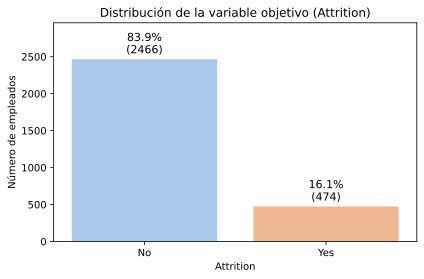

In [337]:
import seaborn as sns
import matplotlib.pyplot as plt


counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100


plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="pastel", legend=False)  # Asignar hue

for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 50, f'{pct:.1f}%\n({count})', ha='center', va='bottom', fontsize=11)

plt.title('Distribución de la variable objetivo (Attrition)')
plt.ylabel('Número de empleados')
plt.xlabel('Attrition')
plt.ylim(0, counts.max() * 1.2)  
plt.tight_layout()
plt.show()

Visualización de variables numéricas

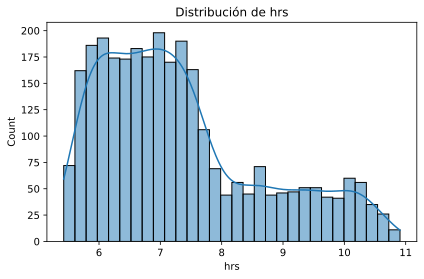

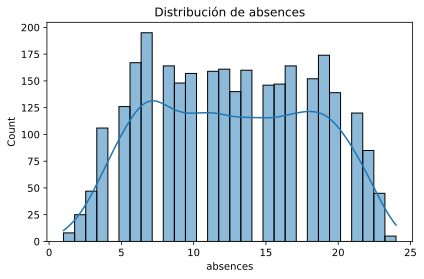

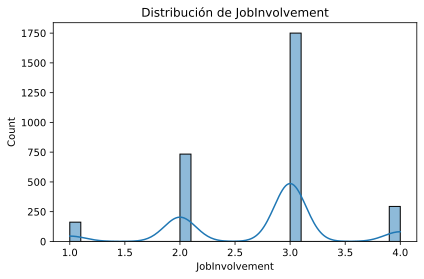

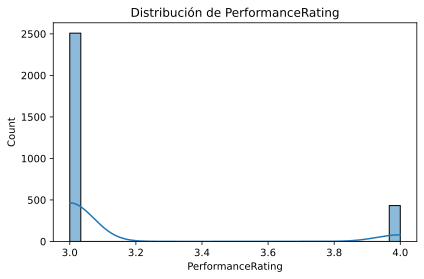

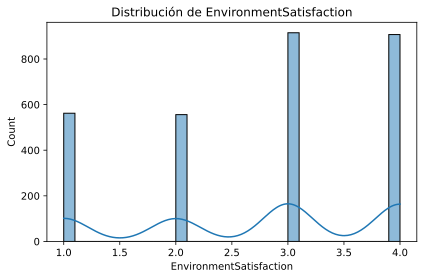

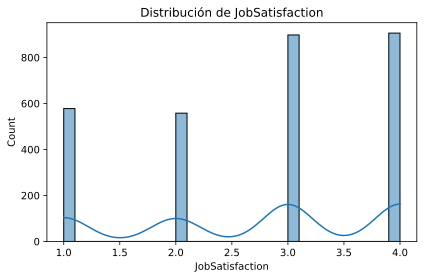

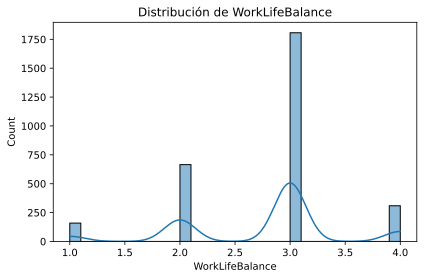

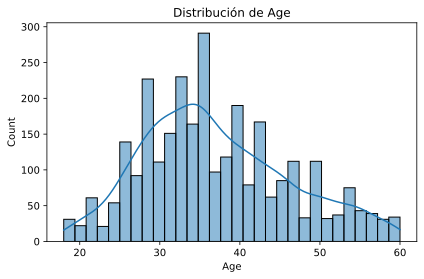

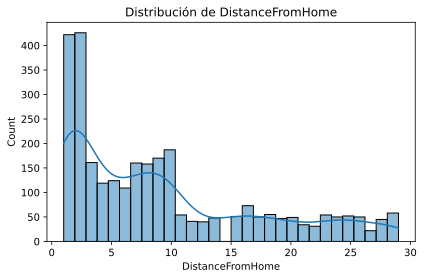

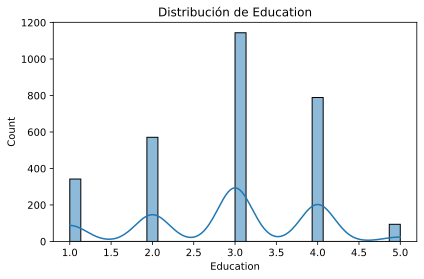

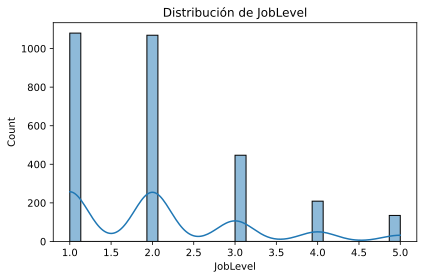

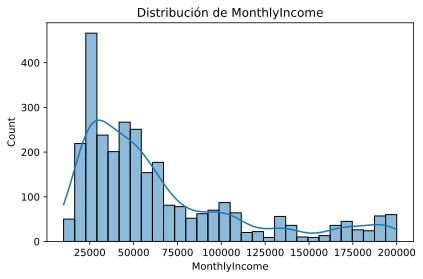

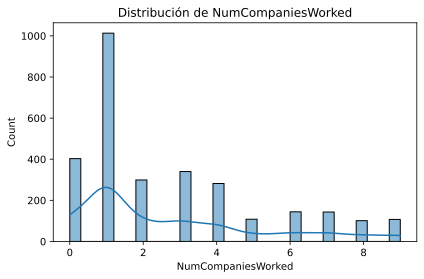

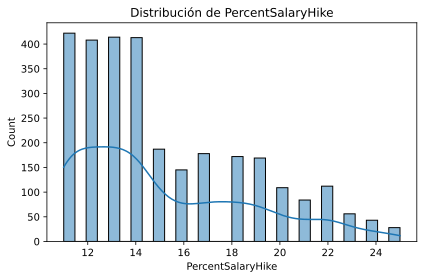

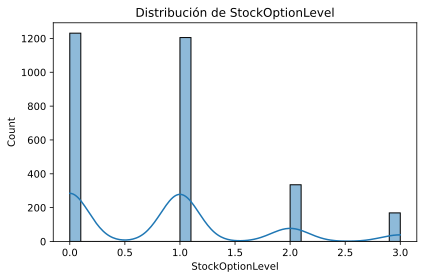

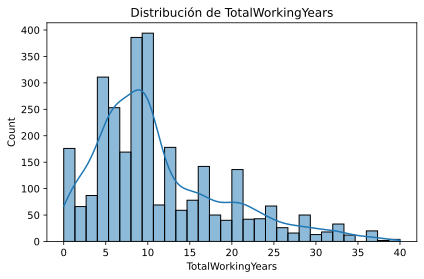

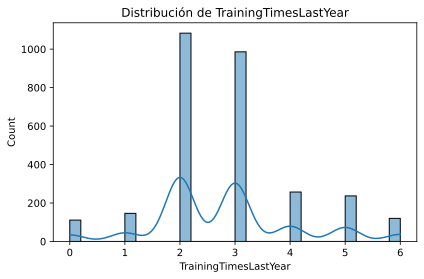

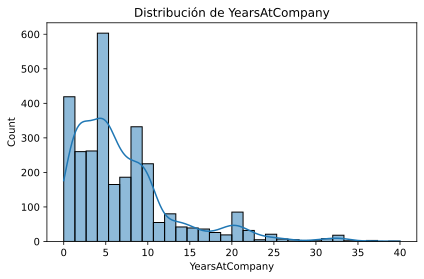

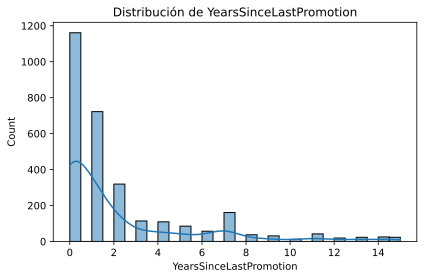

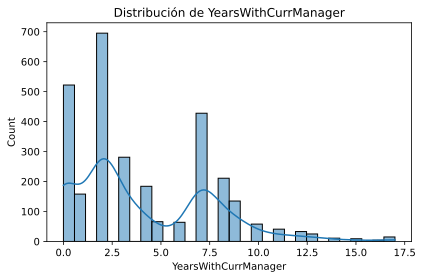

,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,7.322532,12.677551,2.740136,3.146939,2.737075,2.725170,2.770748,36.993878,9.247959,2.905442,2.064626,64739.724490,2.698980,15.165986,0.810204,11.262925,2.790136,6.996939,2.180612,4.115646
std,1.333792,5.544166,0.709020,0.354105,1.092484,1.099652,0.703727,9.182285,8.100429,1.023327,1.101473,47287.321504,2.501214,3.625221,0.852531,7.757418,1.280831,6.076326,3.232675,3.560333
min,5.424757,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,10090.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.276222,8.000000,2.000000,3.000000,2.000000,2.000000,2.000000,30.000000,2.000000,2.000000,1.000000,29077.500000,1.000000,12.000000,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,7.021653,13.000000,3.000000,3.000000,3.000000,3.000000,3.000000,36.000000,7.000000,3.000000,2.000000,48980.000000,2.000000,14.000000,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,7.949262,17.000000,3.000000,3.000000,4.000000,4.000000,3.000000,43.000000,14.000000,4.000000,3.000000,82272.500000,4.000000,18.000000,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,10.907255,24.000000,4.000000,4.000000,4.000000,4.000000,4.000000,60.000000,29.000000,5.000000,5.000000,199990.000000,9.000000,25.000000,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [338]:
import matplotlib.pyplot as plt
import seaborn as sns
target = "Attrition"

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=X, x=col, kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

X[numeric_cols].describe()



##### Viendo los resultados anteriores llego a las siguientes conclusiones:

1. Algunas variables como JobInvolvement, PerformanceRating, EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance, Education o JobLevel tienen valores enteros en escalas de 1 a 4 o  de 1 a 5, lo que me hace pensar que son variables ordinales

2. PerformanceRating y WorkLifeBalance tienen desviaciones estándar muy bajas, lo que indica que la mayoría de los empleados tienen valores similares. Por lo que creo que podrian estar aportando poca informacion al modelo y deberia considerar eliminarlas. 

3. MonthlyIncome destaca por tener una gran dispersión, con valores que van desde 10.090 hasta 199.990, y una desviación típica muy elevada. Este comportamiento sugiere una posible distribución sesgada o la presencia de outliers, que creo que se solucionara mas tarde con el escalado de StandardScaler

Visualización de variables categóricas

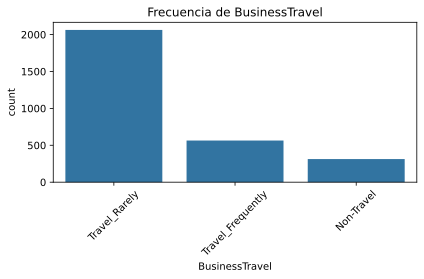

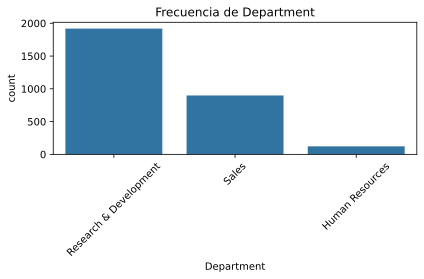

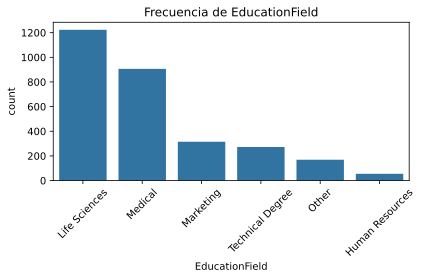

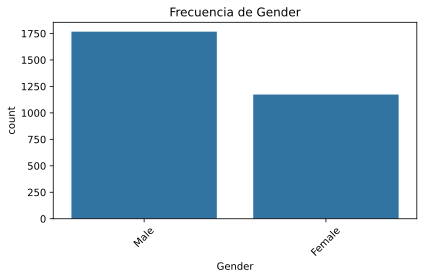

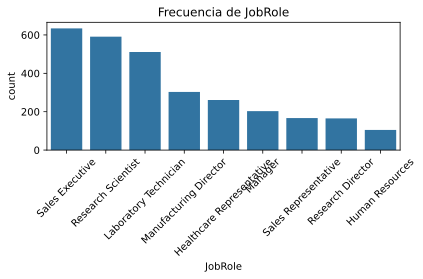

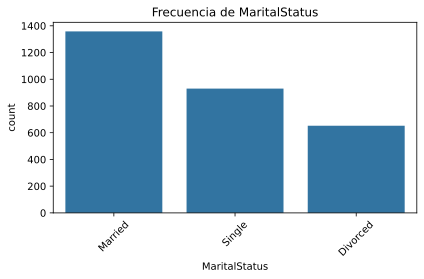

In [339]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=X, x=col, order=X[col].value_counts().index)
    plt.title(f'Frecuencia de {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# HOLDOUT: Datos de entrenamiento y prueba

Divido los datos en conjuntos de entrenamiento (2/3) y prueba (1/3), por la 3-Fold Cross-Validation. Se hace de manera estratificada porque las clases estan desbalanceadas y asi se manetiene la proporcion de clases en los conjuntos de entrenamiento y prueba.



In [340]:
# Dividir los datos en train (2/3) y test (1/3) de forma estratificada
data['attrition'] =  data ['Attrition'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=475965, stratify=y)

# Mostrar tamaños de los conjuntos
print(f"Ejemplos en conjunto de entrenamiento: {len(X_train)}")
print(f"Ejemplos en conjunto de prueba: {len(X_test)}")

# Mostrar distribución de clases en cada conjunto
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True) * 100)

#X.describe() #COMPRUEBO QUE EL COUNT DE TODAS LAS VARIABLES ES EL MISMO
#X_train.isnull().any() #COMPRUEBO QUE NO HAY NULOS
print(X)
print(y)

Ejemplos en conjunto de entrenamiento: 1960
Ejemplos en conjunto de prueba: 980

Distribución de clases en entrenamiento:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Distribución de clases en prueba:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64
            hrs  absences  JobInvolvement  PerformanceRating  \
0      6.420398        19               4                  3   
1      7.615521         7               4                  3   
2      6.093781        18               3                  3   
3      6.460209         5               4                  3   
4     10.384712         2               2                  3   
...         ...       ...             ...                ...   
2935   9.259909        18               4                  3   
2936   6.774531        21               2                  3   
2937   5.673619        21               3                  3   
2938  10.535324         1               3        

En las variables categóricas JobRole y EducationField, la categoría "Human Resources" tiene una presencia muy baja en el conjunto de datos:
En JobRole, representa únicamente el 3.6% de los registros.
En EducationField, apenas alcanza el 1.9%.

Asi evito que el modelo momorice casos raros y genere columnas innecesarias cuando use OneHotEncoder



In [341]:

# Agrupar categorías poco frecuentes en JobRole
X['JobRole'] = X['JobRole'].replace({'Human Resources': 'Other'})

# Agrupar categorías poco frecuentes en EducationField
X['EducationField'] = X['EducationField'].replace({'Human Resources': 'Other'})



Selecciono las variables categóricas y las codifico con OneHotEncoder para pasarlas a variables numericas. 

In [342]:
categorical_columns = X.select_dtypes(include=['object']).columns
# Pipeline para variables categóricas
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),   
    ('pca', PCA())                                         
])
# Verificar las columnas categóricas
print(f"Columnas categóricas: {list(categorical_columns)}")
print(f"Número de columnas categóricas: {len(categorical_columns)}")

Columnas categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Número de columnas categóricas: 6


Elijo el mejor escalador para mi modelo

In [343]:
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}


results = {}

for scaler_name, scaler in scalers.items():
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, numerical_columns),  # Escalar variables numéricas
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)  # Codificar variables categóricas
        ]
    )

    # Crear el pipeline con el preprocesador y KNN
    pipe_knn = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=5))  # Usar K=5 como ejemplo
    ])

    # Validación cruzada
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=5, scoring='accuracy')
    results[scaler_name] = np.mean(scores)
    print(f"{scaler_name}: Accuracy promedio = {np.mean(scores):.4f}")

# Mostrar el mejor escalador
best_scaler = max(results, key=results.get)
print(f"\nEl mejor escalador es: {best_scaler} con un accuracy promedio de {results[best_scaler]:.4f}")

StandardScaler: Accuracy promedio = 0.8408
MinMaxScaler: Accuracy promedio = 0.8276
RobustScaler: Accuracy promedio = 0.8520

El mejor escalador es: RobustScaler con un accuracy promedio de 0.8520


In [344]:

#y = y.map({'No': 0, 'Yes': 1})  

numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
# Pipeline para variables numéricas
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', RobustScaler  ())  
])

Preproceso las dos pipelines con la función ColumnTransformer

In [345]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_columns), 
        ('cat', categorical_pipeline, categorical_columns)  
    ]
)

## --EVALUACION DE MODELOS--


In [346]:
resultados_modelos = {}

Empiezo con el modelo dummy, que tiene un rendimineto bajo porque no realiza predicciones.

In [347]:

# Crear el modelo DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")  # Predice siempre la clase mayoritaria

# Entrenar el modelo DummyClassifier con los datos originales
dummy_clf.fit(X_train, y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred_dummy = dummy_clf.predict(X_test)

# Métricas de evaluación
balanced_accuracy = balanced_accuracy_score(y_test, y_pred_dummy)

print("Balanced Accuracy del modelo Dummy:", balanced_accuracy_score(y_test, y_pred_dummy))
print("\nReporte de clasificación del modelo Dummy:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))
resultados_modelos['DummyClassifier'] = balanced_accuracy

Balanced Accuracy del modelo Dummy: 0.5

Reporte de clasificación del modelo Dummy:
              precision    recall  f1-score   support

          No       0.84      1.00      0.91       822
         Yes       0.00      0.00      0.00       158

    accuracy                           0.84       980
   macro avg       0.42      0.50      0.46       980
weighted avg       0.70      0.84      0.77       980



Para el clasificador, creo un pipeline para unir el preproceso (indico que el problema esta desbalanceado). Como el dataset está desbalanceado uso como mejor resultado "balanced_accuracy"

In [348]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('pca', PCA()),  
    ('classifier', tree.DecisionTreeClassifier(class_weight='balanced', random_state=475965))  
])

cv_score = cross_val_score(clf, X_train, y_train, cv=5, scoring="balanced_accuracy").mean()

print(f"Balanced Accuracy promedio en validación cruzada: {cv_score:.4f}")
resultados_modelos['Validacion cruzada'] = cv_score

Balanced Accuracy promedio en validación cruzada: 0.6818


Creo que mi bajo accuracy se puede deber a que utilizo hiperparametros predeterminados, por lo que ahora busco los mejores hiperparametros con GridSearch

In [349]:
param_grid = {
    'pca__n_components': [5, 10, 15, 20],  # Número de componentes principales
    'classifier__max_depth': [3, 5, 10, None],  # Profundidad máxima del árbol
    'classifier__min_samples_split': [2, 5, 10],  # Muestras mínimas para dividir un nodo
    'classifier__min_samples_leaf': [1, 2, 4]  # Muestras mínimas en una hoja
}

In [350]:
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="balanced_accuracy",  
    cv=5,                        
    verbose=1,
    n_jobs=-1                     
)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el modelo con los mejores hiperparámetros usando validación cruzada
best_model = grid_search.best_estimator_
cv_score = cross_val_score(best_model, X_train, y_train, cv=5, scoring="balanced_accuracy").mean()

print(f"Balanced Accuracy con validación cruzada + GridSearch: {cv_score:.4f}")

# Evaluar el modelo en el conjunto de prueba
y_pred = best_model.predict(X_test)
final_score = cross_val_score(best_model, X_test, y_test, cv=5, scoring="balanced_accuracy").mean()

print(f"Balanced Accuracy en el conjunto de prueba: {final_score:.4f}")

resultados_modelos['Gridsearch con hiperparametros'] = final_score

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejores hiperparámetros: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'pca__n_components': 20}
Balanced Accuracy con validación cruzada + GridSearch: 0.7684
Balanced Accuracy en el conjunto de prueba: 0.6266


## Búsqueda aleatoria de hiperparametros (RANDOMIZED SEARCH)

In [351]:
# Distribuciones de parámetros para el pipeline categórico sin PCA
cat_transformer_dist = {
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant']  # Estrategias de imputación
}

# Distribuciones de parámetros para el pipeline numérico
num_transformer_dist = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],  # Estrategias para imputar valores numéricos
    #'preprocessor__num__scaler__feature_range': [(0, 1), (0, 10)]  # Rango de escalado
}
pca_dist = {
    'pca__n_components': [5, 10, 15, 20, None]  
}
# Distribuciones de parámetros para el clasificador
decision_tree_dist = {
    'classifier__max_depth': list(range(2, 20)),  # Profundidad máxima del árbol
    'classifier__min_samples_split': list(range(2, 20)),  # Muestras mínimas para dividir un nodo
    'classifier__min_samples_leaf': list(range(1, 10))  # Muestras mínimas en una hoja
}

# Combinar todas las distribuciones de parámetros
param_dist = {**num_transformer_dist, **cat_transformer_dist, **decision_tree_dist}

Hago la búsqueda aleatorica de hiperparámetros y la evalúo

In [352]:
random_search = RandomizedSearchCV(
    estimator=clf,  
    param_distributions=param_dist,
    n_iter=100,  
    scoring="balanced_accuracy", 
    cv=5,  
    verbose=1,
    random_state=475965,
    n_jobs=-1  
)


In [353]:
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               Index(['hrs', 'absences', 'JobInvolvement', 'PerformanceRating',
       'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age',
       'DistanceFromHome', 'Education', 'JobLevel', 'M...
                                                                  7, 8, 9, 10,
                                                                  11, 12, 13,
                                                                  14, 15, 16,
                                                                  17, 18, 19],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         3, 4,
                                                                         5, 6,
                                                                         7, 8,
                                                                         9],
                                        'classifier__min_samples_split': [2, 3,
                                                                          4, 5,
                                                                          6, 7,
                                                                          8, 9,
                                                                          10,
                                                                          11,
                                                                          12,
                                                                          13,
                                                                          14,
                                                                          15,
                                                                          16,
                                                                          17,
                                                                          18,
                                                                          19],
                                        'preprocessor__cat__imputer__strategy': ['most_frequent',
                                                                                 'constant'],
                                        'preprocessor__num__imputer__strategy': ['mean',
                                                                                 'median']},
                   random_state=475965, scoring='balanced_accuracy', verbose=1)

In [354]:
random_search.best_score_

np.float64(0.7268645207823659)

In [355]:
random_search.best_params_

{'preprocessor__num__imputer__strategy': 'median',
 'preprocessor__cat__imputer__strategy': 'constant',
 'classifier__min_samples_split': 2,
 'classifier__min_samples_leaf': 2,
 'classifier__max_depth': 9}

In [356]:
y_pred = random_search.predict(X_test)
y_pred[:10]

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes'],
      dtype=object)

In [357]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.93      0.84      0.88       822
         Yes       0.45      0.69      0.55       158

    accuracy                           0.82       980
   macro avg       0.69      0.77      0.72       980
weighted avg       0.86      0.82      0.83       980



In [358]:
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"El valor de balanced accuracy: {balanced_accuracy_score(y_test, y_pred)}")
resultados_modelos['Random Search con hiperparametros'] = balanced_acc

El valor de balanced accuracy: 0.7652530105639226


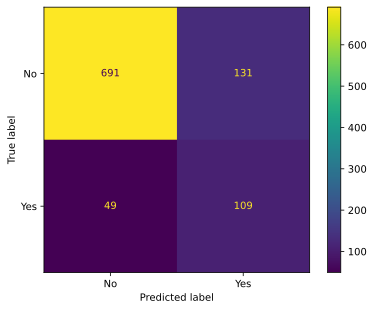

In [359]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=random_search.classes_)
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_search.classes_)
disp.plot()
plt.show()

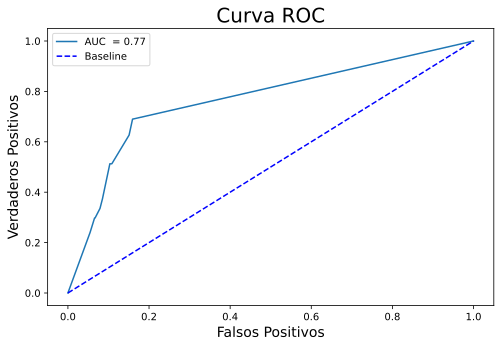

In [360]:
# Convertir y_test a valores binarios
y_test_binary = y_test.map({'Yes': 1, 'No': 0})

# Calcular el AUC y la curva ROC
probs = random_search.predict_proba(X_test)[:, 1]
auc = metrics.roc_auc_score(y_test_binary, probs)
fpr, tpr, thresholds = metrics.roc_curve(y_test_binary, probs)

# Graficar la curva ROC
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'AUC  = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Baseline')
plt.title('Curva ROC', size=20)
plt.xlabel('Falsos Positivos', size=14)
plt.ylabel('Verdaderos Positivos', size=14)
plt.legend()
plt.show()

In [361]:
print(y_train.dtypes)
print(y_train.head())

object
2494    No
989     No
798     No
174     No
138     No
Name: Attrition, dtype: object


## Modelo KNN

Balanced Accuracy (KNN sin GridSearch): 0.6205


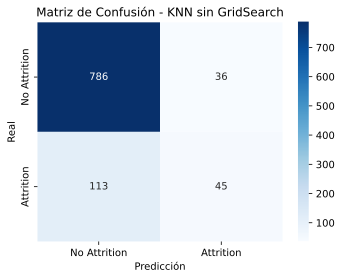

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.67105777 0.81698389 0.62422542 0.79512882 0.60653215 0.76455033
 0.57099531 0.73757399        nan 0.83555895        nan 0.84128076
        nan 0.82376346        nan 0.8085002 ]
  warnings.warn(


Balanced Accuracy (KNN con GridSearch): 0.8884


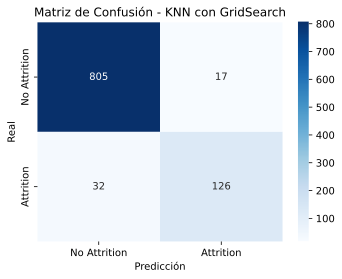

In [362]:
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# **1. KNN sin GridSearch**
pipe_knn_default = Pipeline([
    ('preprocessor', preprocessor),  # Preprocesador (ya definido en tu código)
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Modelo KNN con 5 vecinos
])

# Entrenar el modelo
pipe_knn_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_knn_default = pipe_knn_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_knn_default = balanced_accuracy_score(y_test, y_pred_knn_default)
print(f"Balanced Accuracy (KNN sin GridSearch): {balanced_acc_knn_default:.4f}")
resultados_modelos['KNN sin GridSearch'] = balanced_acc_knn_default

# Matriz de confusión
cm_knn_default = confusion_matrix(y_test, y_pred_knn_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn_default, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - KNN sin GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# **2. KNN con GridSearch**
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],  # Número de vecinos
    'knn__weights': ['uniform', 'distance'],  # Peso de los vecinos
    'knn__metric': ['euclidean', 'manhattan']  # Métrica de distancia
}

pipe_knn_grid = Pipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('knn', KNeighborsClassifier())  # Modelo KNN
])

grid_search = GridSearchCV(pipe_knn_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_knn = grid_search.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_knn_grid = best_knn.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_knn_grid = balanced_accuracy_score(y_test, y_pred_knn_grid)
print(f"Balanced Accuracy (KNN con GridSearch): {balanced_acc_knn_grid:.4f}")
resultados_modelos['KNN con GridSearch'] = balanced_acc_knn_grid

# Matriz de confusión
cm_knn_grid = confusion_matrix(y_test, y_pred_knn_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - KNN con GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


## KNN con SMOTE

Balanced Accuracy (KNN con SMOTE y sin GridSearch): 0.7674


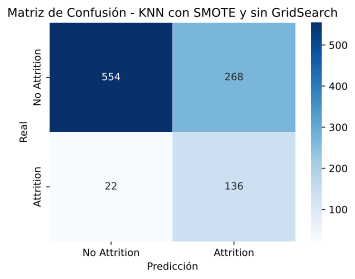

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.79536375 0.85285133 0.76247851 0.83378362 0.74178905 0.82563299
 0.72497104 0.81601034        nan 0.84760916        nan 0.84818051
        nan 0.84470259        nan 0.85314068]
  warnings.warn(


Balanced Accuracy (KNN con SMOTE y con GridSearch): 0.8924


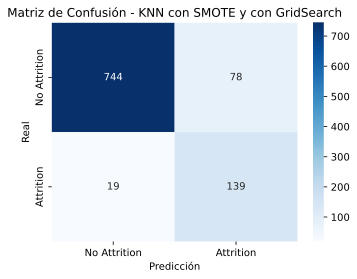

In [363]:

# **3. KNN con SMOTE y sin GridSearch**
pipe_knn_smote_default = ImbPipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Modelo KNN con 5 vecinos
])

# Entrenar el modelo con SMOTE
pipe_knn_smote_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_knn_smote_default = pipe_knn_smote_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_knn_smote_default = balanced_accuracy_score(y_test, y_pred_knn_smote_default)
print(f"Balanced Accuracy (KNN con SMOTE y sin GridSearch): {balanced_acc_knn_smote_default:.4f}")
resultados_modelos['KNN con SMOTE y sin GridSearch'] = balanced_acc_knn_smote_default

# Matriz de confusión
cm_knn_smote_default = confusion_matrix(y_test, y_pred_knn_smote_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn_smote_default, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - KNN con SMOTE y sin GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# **4. KNN con SMOTE y con GridSearch**
pipe_knn_smote_grid = ImbPipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('knn', KNeighborsClassifier())  # Modelo KNN
])

grid_search_smote = GridSearchCV(pipe_knn_smote_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_smote.fit(X_train, y_train)

# Obtener el mejor modelo
best_knn_smote = grid_search_smote.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_knn_smote_grid = best_knn_smote.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_knn_smote_grid = balanced_accuracy_score(y_test, y_pred_knn_smote_grid)
print(f"Balanced Accuracy (KNN con SMOTE y con GridSearch): {balanced_acc_knn_smote_grid:.4f}")
resultados_modelos['KNN con SMOTE y con GridSearch'] = balanced_acc_knn_smote_grid

# Matriz de confusión
cm_knn_smote_grid = confusion_matrix(y_test, y_pred_knn_smote_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn_smote_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - KNN con SMOTE y con GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()



## Arbol de decision

Balanced Accuracy (Árbol de Decisión sin GridSearch): 0.7842


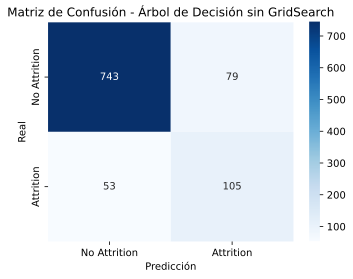

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Balanced Accuracy (Árbol de Decisión con GridSearch): 0.7603

Mejores hiperparámetros encontrados por GridSearch:
{'clasificador__max_depth': 10, 'clasificador__min_samples_leaf': 1, 'clasificador__min_samples_split': 10}


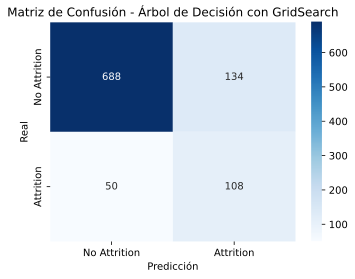

In [364]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Árbol de Decisión sin GridSearch**
# Crear el pipeline para el árbol de decisión con hiperparámetros predeterminados
pipe_tree_default = Pipeline([
    ('preproceso', preprocessor),  # Preprocesamiento (imputación, escalado, etc.)
    ('clasificador', DecisionTreeClassifier(random_state=475965, class_weight='balanced', criterion='entropy'))  # Árbol de decisión
])

# Entrenar el modelo
pipe_tree_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_tree_default = pipe_tree_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_tree_default = balanced_accuracy_score(y_test, y_pred_tree_default)
print(f"Balanced Accuracy (Árbol de Decisión sin GridSearch): {balanced_acc_tree_default:.4f}")

# Guardar el resultado en el diccionario
resultados_modelos['Árbol de Decisión sin GridSearch'] = balanced_acc_tree_default

# Matriz de confusión para el modelo sin GridSearch
cm_tree_default = confusion_matrix(y_test, y_pred_tree_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree_default, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - Árbol de Decisión sin GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# **2. Árbol de Decisión con GridSearch**
# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'clasificador__max_depth': [3, 5, 10, None],  # Profundidad máxima del árbol
    'clasificador__min_samples_split': [2, 5, 10, 20],  # Muestras mínimas para dividir un nodo
    'clasificador__min_samples_leaf': [1, 2, 4, 8]  # Muestras mínimas en una hoja
}

# Crear el pipeline para el árbol de decisión
pipe_tree_grid = Pipeline([
    ('preproceso', preprocessor),  # Preprocesamiento
    ('clasificador', DecisionTreeClassifier(random_state=42, class_weight='balanced'))  # Árbol de decisión
])

# Configurar GridSearchCV
grid_search = GridSearchCV(pipe_tree_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)

# Entrenar el modelo con GridSearch
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_tree = grid_search.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_tree_grid = best_tree.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_tree_grid = balanced_accuracy_score(y_test, y_pred_tree_grid)
print(f"Balanced Accuracy (Árbol de Decisión con GridSearch): {balanced_acc_tree_grid:.4f}")

# Guardar el resultado en el diccionario
resultados_modelos['Árbol de Decisión con GridSearch'] = balanced_acc_tree_grid

# Mostrar los mejores hiperparámetros
print("\nMejores hiperparámetros encontrados por GridSearch:")
print(grid_search.best_params_)

# Matriz de confusión para el modelo con GridSearch
cm_tree_grid = confusion_matrix(y_test, y_pred_tree_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - Árbol de Decisión con GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


## Árbol de decisión con SMOTE

Balanced Accuracy (Árbol de Decisión sin GridSearch con SMOTE): 0.8117
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Balanced Accuracy (Árbol de Decisión con GridSearch con SMOTE): 0.7814

Mejores hiperparámetros encontrados por GridSearch:
{'clasificador__max_depth': 10, 'clasificador__min_samples_leaf': 1, 'clasificador__min_samples_split': 5}


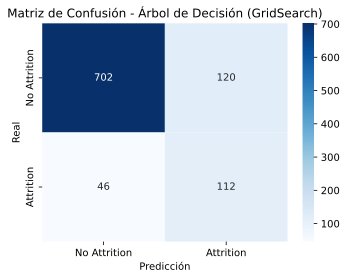

In [365]:
# **2. Pipeline con SMOTE**
# Crear el pipeline con preprocesador y SMOTE
pipe_tree_default = ImbPipeline([
    ('preproceso', preprocessor),  # Preprocesamiento
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('clasificador', DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion='entropy'))  # Árbol de decisión
])

# Entrenar el modelo
pipe_tree_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_tree_default = pipe_tree_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_tree_default = balanced_accuracy_score(y_test, y_pred_tree_default)
print(f"Balanced Accuracy (Árbol de Decisión sin GridSearch con SMOTE): {balanced_acc_tree_default:.4f}")

# Guardar el resultado en el diccionario
resultados_modelos['Árbol de Decisión sin GridSearch con SMOTE'] = balanced_acc_tree_default

# **3. Árbol de Decisión con GridSearch**
param_grid = {
    'clasificador__max_depth': [3, 5, 10, 15, None],
    'clasificador__min_samples_split': [2, 5, 10, 20],
    'clasificador__min_samples_leaf': [1, 2, 4, 8]
}

pipe_tree_grid = ImbPipeline([
    ('preproceso', preprocessor),  # Preprocesamiento
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('clasificador', DecisionTreeClassifier(random_state=42, class_weight='balanced'))  # Árbol de decisión
])

grid_search = GridSearchCV(pipe_tree_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_tree = grid_search.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_tree_grid = best_tree.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_tree_grid = balanced_accuracy_score(y_test, y_pred_tree_grid)
print(f"Balanced Accuracy (Árbol de Decisión con GridSearch con SMOTE): {balanced_acc_tree_grid:.4f}")

# Guardar el resultado en el diccionario
resultados_modelos['Árbol de Decisión con GridSearch con SMOTE'] = balanced_acc_tree_grid

# Mostrar los mejores hiperparámetros
print("\nMejores hiperparámetros encontrados por GridSearch:")
print(grid_search.best_params_)

# **Visualización de resultados**
cm_tree_grid = confusion_matrix(y_test, y_pred_tree_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - Árbol de Decisión (GridSearch)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Regresión logística con copi

Balanced Accuracy (Regresión Logística sin GridSearch): 0.7125


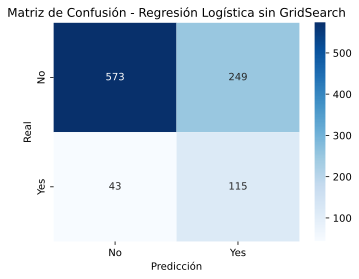

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Balanced Accuracy (Regresión Logística con GridSearch): 0.7088


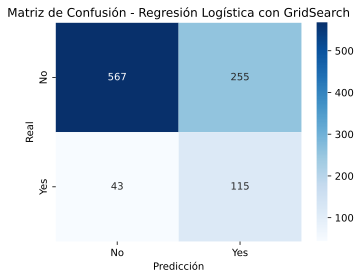

In [366]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Regresión Logística sin GridSearch**
pipe_logreg_default = Pipeline([
    ('preprocessor', preprocessor),  # Preprocesador (ya definido en tu código)
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=475965))  # Modelo de regresión logística
])

# Entrenar el modelo
pipe_logreg_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_logreg_default = pipe_logreg_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_logreg_default = balanced_accuracy_score(y_test, y_pred_logreg_default)
print(f"Balanced Accuracy (Regresión Logística sin GridSearch): {balanced_acc_logreg_default:.4f}")
resultados_modelos['Regresión Logística sin GridSearch'] = balanced_acc_logreg_default

# Matriz de confusión
cm_logreg_default = confusion_matrix(y_test, y_pred_logreg_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_default, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusión - Regresión Logística sin GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# **2. Regresión Logística con GridSearch**
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],  # Regularización
    'logreg__solver': ['lbfgs', 'liblinear']  # Solvers
}

pipe_logreg_grid = Pipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=475965))  # Modelo de regresión logística
])

grid_search = GridSearchCV(pipe_logreg_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
best_logreg = grid_search.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_logreg_grid = best_logreg.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_logreg_grid = balanced_accuracy_score(y_test, y_pred_logreg_grid)
print(f"Balanced Accuracy (Regresión Logística con GridSearch): {balanced_acc_logreg_grid:.4f}")
resultados_modelos['Regresión Logística con GridSearch'] = balanced_acc_logreg_grid

# Matriz de confusión
cm_logreg_grid = confusion_matrix(y_test, y_pred_logreg_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusión - Regresión Logística con GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()



## Regresión logística con SMOTE

Balanced Accuracy (Regresión Logística con SMOTE y sin GridSearch): 0.7097


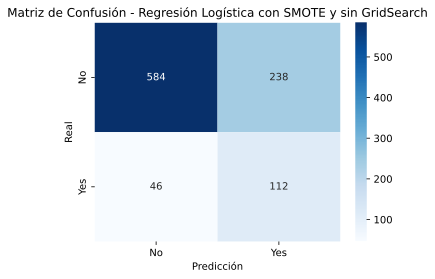

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Balanced Accuracy (Regresión Logística con SMOTE y con GridSearch): 0.7098


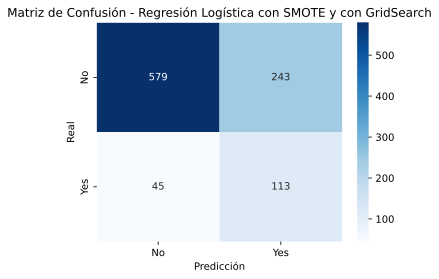

In [367]:

# **3. Regresión Logística con SMOTE y sin GridSearch**
pipe_logreg_smote_default = ImbPipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=475965))  # Modelo de regresión logística
])

# Entrenar el modelo con SMOTE
pipe_logreg_smote_default.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_logreg_smote_default = pipe_logreg_smote_default.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_logreg_smote_default = balanced_accuracy_score(y_test, y_pred_logreg_smote_default)
print(f"Balanced Accuracy (Regresión Logística con SMOTE y sin GridSearch): {balanced_acc_logreg_smote_default:.4f}")
resultados_modelos['Regresión Logística con SMOTE y sin GridSearch'] = balanced_acc_logreg_smote_default

# Matriz de confusión
cm_logreg_smote_default = confusion_matrix(y_test, y_pred_logreg_smote_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_smote_default, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusión - Regresión Logística con SMOTE y sin GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# **4. Regresión Logística con SMOTE y con GridSearch**
pipe_logreg_smote_grid = ImbPipeline([
    ('preprocessor', preprocessor),  # Preprocesador
    ('smote', SMOTE(random_state=42)),  # Aplicar SMOTE
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=475965))  # Modelo de regresión logística
])

grid_search_smote = GridSearchCV(pipe_logreg_smote_grid, param_grid, scoring='balanced_accuracy', cv=5, verbose=1, n_jobs=-1)
grid_search_smote.fit(X_train, y_train)

# Obtener el mejor modelo
best_logreg_smote = grid_search_smote.best_estimator_

# Predecir en el conjunto de prueba con el mejor modelo
y_pred_logreg_smote_grid = best_logreg_smote.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_logreg_smote_grid = balanced_accuracy_score(y_test, y_pred_logreg_smote_grid)
print(f"Balanced Accuracy (Regresión Logística con SMOTE y con GridSearch): {balanced_acc_logreg_smote_grid:.4f}")
resultados_modelos['Regresión Logística con SMOTE y con GridSearch'] = balanced_acc_logreg_smote_grid

# Matriz de confusión
cm_logreg_smote_grid = confusion_matrix(y_test, y_pred_logreg_smote_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg_smote_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusión - Regresión Logística con SMOTE y con GridSearch')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [368]:
# Calcular el R² en el conjunto de prueba
r2_score = pipe_logreg.score(X_test, y_test_binary)
print(f"R² en el conjunto de prueba: {r2_score:.4f}")

# Calcular el RMSE en el conjunto de prueba
from sklearn.metrics import mean_squared_error
y_pred = pipe_logreg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_binary, y_pred))
print(f"RMSE en el conjunto de prueba: {rmse:.4f}")

R² en el conjunto de prueba: 0.7204
RMSE en el conjunto de prueba: 0.5288


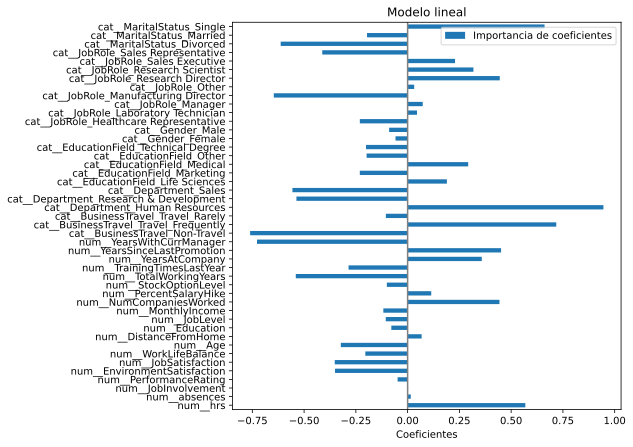

In [369]:
feature_names = pipe_logreg[:-1].get_feature_names_out()
coef_values = pipe_logreg.named_steps['clasificador'].coef_.ravel()  # <- aplanado correcto

coefs = pd.DataFrame(
    coef_values,
    columns=["Importancia de coeficientes"],
    index=feature_names
)
coefs.plot.barh(figsize=(9, 7))
plt.title("Modelo lineal")
plt.xlabel("Coeficientes")
plt.axvline(x=0, color=".5")
plt.subplots_adjust(left=0.3)

## Random Forest

In [370]:
clf_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=5)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=475965))
])

In [371]:
param_grid_rf = {
    'pca__n_components': [5, 10, 15],  # Número de componentes principales
    'classifier__n_estimators': [100, 200, 300],  # Número de árboles en el bosque
    'classifier__max_depth': [None, 10, 20],  # Profundidad máxima de los árboles
    'classifier__min_samples_split': [2, 5, 10],  # Muestras mínimas para dividir un nodo
    'classifier__min_samples_leaf': [1, 2, 4]  # Muestras mínimas en una hoja
}

In [372]:
grid_search_rf = GridSearchCV(
    estimator=clf_rf,
    param_grid=param_grid_rf,
    scoring="balanced_accuracy",  
    cv=5,                        
    verbose=1,
    n_jobs=-1                     
)
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
balanced_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

print("MEjores parametros con GridSearch:")
print(grid_search_rf.best_params_)
print(f"Balanced Accuracy en test: {balanced_acc_rf:.4f}")

resultados_modelos['Random Forest + GridSearch (sin SMOTE)'] = balanced_acc_rf

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
MEjores parametros con GridSearch:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300, 'pca__n_components': 15}
Balanced Accuracy en test: 0.7943


Creo la matriz de confusion para Random Forest:

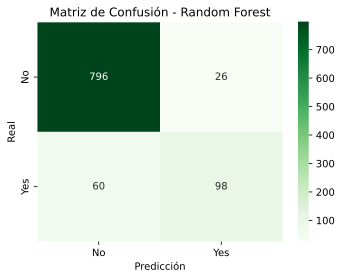

In [373]:
y_pred_rf = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


## SVM

Balanced Accuracy (SVM): 0.8439

Reporte de Clasificación (SVM):
              precision    recall  f1-score   support

No Attrition       0.96      0.86      0.91       822
   Attrition       0.54      0.82      0.65       158

    accuracy                           0.86       980
   macro avg       0.75      0.84      0.78       980
weighted avg       0.89      0.86      0.87       980



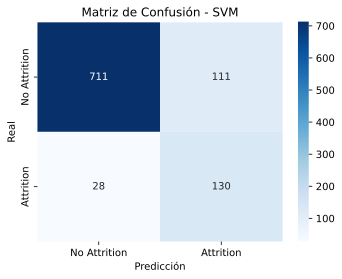

In [374]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


categorical_columns = X_train.select_dtypes(include=['object']).columns
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Imputar valores faltantes numéricos
            ('scaler', RobustScaler ())  # Escalar características numéricas
        ]), numerical_columns),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputar valores faltantes categóricos
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codificar variables categóricas
        ]), categorical_columns)
    ]
)

# Crear el pipeline para SVM
pipe_svm = Pipeline([
    ('preproceso', preprocessor),  # Preprocesamiento (imputación, escalado, etc.)
    ('clasificador', SVC(kernel='rbf', class_weight='balanced', random_state=475965))  # SVM con kernel RBF
])

# Entrenar el modelo
pipe_svm.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_svm = pipe_svm.predict(X_test)

# Calcular Balanced Accuracy
balanced_acc_svm = balanced_accuracy_score(y_test, y_pred_svm)
print(f"Balanced Accuracy (SVM): {balanced_acc_svm:.4f}")

# Reporte de clasificación
print("\nReporte de Clasificación (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=['No Attrition', 'Attrition']))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Prueba del modelo LightGBM

Este modelo me lo ha propuesto chatgpt. Tengo que estudairlo aun y luego probare a hacer con sus hiperparametros gridsearch

In [375]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score

# Crear pipeline con preprocesador, SMOTE y LightGBM
lgbm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),         # Codificación y escalado
    ('smote', SMOTE(random_state=475965)),      # SMOTE aplicado tras codificar
    ('classifier', lgb.LGBMClassifier(random_state=475965, class_weight='balanced'))
])

# Evaluar con validación cruzada
lgbm_score = cross_val_score(
    lgbm_pipeline,
    X_train, y_train,
    cv=5,
    scoring='balanced_accuracy'
).mean()

print(f"Balanced Accuracy (LightGBM con SMOTE): {lgbm_score:.4f}")

resultados_modelos['LightGBM con SMOTE'] = lgbm_score



[LightGBM] [Info] Number of positive: 1315, number of negative: 1315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6766
[LightGBM] [Info] Number of data points in the train set: 2630, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1315, number of negative: 1315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6571
[LightGBM] [Info] Number of data points in the train set: 2630, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1315, number of negative: 1315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6926
[LightGBM] [Info] Number of data points in the train set: 2630, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1315, number of negative: 1315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6774
[LightGBM] [Info] Number of data points in the train set: 2630, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1316, number of negative: 1316
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6787
[LightGBM] [Info] Number of data points in the train set: 2632, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Balanced Accuracy (LightGBM con SMOTE): 0.8413


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [376]:
from sklearn.metrics import balanced_accuracy_score

# Entrenar el modelo completo antes de predecir
lgbm_pipeline.fit(X_train, y_train)

# Predecir probabilidades sobre el conjunto de prueba
y_probs = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Probar con distintos umbrales y guardar los resultados
for threshold in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_adjusted = (y_probs >= threshold).astype(int)
    score = balanced_accuracy_score(y_test_binary, y_pred_adjusted)
    print(f"Balanced Accuracy con umbral {threshold}: {score:.4f}")
    resultados_modelos[f'LightGBM + Umbral {threshold}'] = score  # 📝 Guardar cada resultado


[LightGBM] [Info] Number of positive: 1644, number of negative: 1644
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7965
[LightGBM] [Info] Number of data points in the train set: 3288, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Balanced Accuracy con umbral 0.5: 0.8827
Balanced Accuracy con umbral 0.45: 0.8821
Balanced Accuracy con umbral 0.4: 0.8929
Balanced Accuracy con umbral 0.35: 0.8924
Balanced Accuracy con umbral 0.3: 0.8969


c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# SMOTE

### Tablas de visualizacion

In [377]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd


metricas_modelos = {}


modelos = {
    'RandomizedSearch (LightGBM)': random_search,
    'Regresión Logística': pipe_logreg,
    'Random Forest': best_rf,
    'LightGBM + SMOTE': lgbm_pipeline
}

# Calcular métricas
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    
    # Asegurarse de que las predicciones estén en el mismo formato que y_test
    if y_pred.dtype == 'object':  # Si las predicciones están en formato texto
        y_pred = pd.Series(y_pred).map({'No': 0, 'Yes': 1}).values  # Convertir a numérico
    
    # Calcular métricas
    metricas_modelos[nombre] = {
        'Accuracy': accuracy_score(y_test_binary, y_pred),
        'Precision (Yes)': precision_score(y_test_binary, y_pred, pos_label=1),
        'Recall (Yes)': recall_score(y_test_binary, y_pred, pos_label=1),
        'F1-Score (Yes)': f1_score(y_test_binary, y_pred, pos_label=1)
    }

# Mostrar tabla comparativa
df_metricas = pd.DataFrame(metricas_modelos).T
display(df_metricas.style.background_gradient(cmap='Blues').format("{:.2f}"))

c:\Users\clave\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision (Yes),Recall (Yes),F1-Score (Yes)
RandomizedSearch (LightGBM),0.82,0.45,0.69,0.55
Regresión Logística,0.72,0.33,0.74,0.46
Random Forest,0.91,0.79,0.62,0.70
LightGBM + SMOTE,0.95,0.89,0.78,0.83


Tabla para ver lso accuracy de todos mis modelos

,Balanced Accuracy
DummyClassifier,0.500000
KNN sin GridSearch,0.620507
Gridsearch con hiperparametros,0.626574
Validacion cruzada,0.681771
Regresión Logística con GridSearch,0.708815
Regresión Logística con SMOTE y sin GridSearch,0.709662
Regresión Logística con SMOTE y con GridSearch,0.709785
Regresión Logística sin GridSearch,0.712464
Árbol de Decisión con GridSearch,0.760264
Random Search con hiperparametros,0.765253


<Figure size 1000x600 with 0 Axes>

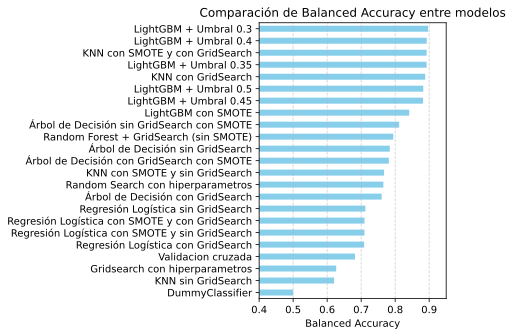

In [378]:
import pandas as pd
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame.from_dict(resultados_modelos, orient='index', columns=['Balanced Accuracy'])
df_resultados = df_resultados.sort_values(by='Balanced Accuracy')

display(df_resultados)


plt.figure(figsize=(10, 6))
df_resultados.plot(kind='barh', legend=False, color='skyblue')
plt.title('Comparación de Balanced Accuracy entre modelos')
plt.xlabel('Balanced Accuracy')
plt.xlim(0.4, 0.95)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [379]:
# Modelo final
modelo_final = random_search.best_estimator_
_ = modelo_final.fit (X,y)
